<a href="https://colab.research.google.com/github/asmamest/ML_Projects/blob/Detecting-Chimical-Process-Faults/Statistic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.0/416.0 kB 5.7 MB/s eta 0:00:00


In [5]:
import pyreadr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**The TEP variables (columns 4 to 55 ) were sampled every 3 minutes for a total duration of 25 hours respectively .**

**The faults were introduced 1 hour into the Faulty Training and 8 hours into Faulty Testing datasets .**

In [6]:
# Only Training data is used

df_FaultFree = pyreadr.read_r(r'/content/drive/MyDrive/Projets/TEP/Datasets/TEP_FaultFree_Training.RData')['fault_free_training']
df_Faulty = pyreadr.read_r(r'/content/drive/MyDrive/Projets/TEP/Datasets/TEP_Faulty_Training.RData')['faulty_training']

In [18]:
# Calculate Summary Statistics for each Df  for simulationRun ==1 :
def calculate_summary(df,label):
  summary=df[df['simulationRun']==1].iloc[:,3:].describe()
  print(f"summary_{label} ")
  print(summary)
  return summary

calculate_summary(df_FaultFree,"FaultFree")
calculate_summary(df_Faulty,"Faulty")



summary_FaultFree 
          xmeas_1      xmeas_2      xmeas_3     xmeas_4     xmeas_5  \
count  500.000000   500.000000   500.000000  500.000000  500.000000   
mean     0.250589  3662.773200  4509.577200    9.344804   26.907058   
std      0.028053    32.682159    38.719848    0.078888    0.214969   
min      0.163350  3564.600000  4400.500000    9.126600   26.201000   
25%      0.232368  3642.825000  4484.500000    9.287200   26.761000   
50%      0.249795  3661.750000  4506.200000    9.345900   26.908000   
75%      0.268678  3682.400000  4536.475000    9.399450   27.056250   
max      0.336420  3775.000000  4613.400000    9.575700   27.501000   

          xmeas_6      xmeas_7     xmeas_8     xmeas_9    xmeas_10  ...  \
count  500.000000   500.000000  500.000000  500.000000  500.000000  ...   
mean    42.340676  2704.357000   75.017246  120.400040    0.337032  ...   
std      0.220381     5.970479    0.527373    0.019513    0.011672  ...   
min     41.796000  2692.300000   73.67700

,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.266325,3661.164830,4505.516690,9.348639,26.904850,42.353603,2717.108280,74.963209,120.400601,0.346801,...,53.837961,30.927638,62.570665,21.151210,40.360206,38.251749,46.558399,51.465879,43.084767,19.728465
std,0.146969,42.245927,105.971562,0.306214,0.236367,0.293656,70.113404,1.224814,0.072286,0.085449,...,2.182148,20.180334,5.443094,4.696159,12.368467,3.014745,2.384102,17.074236,9.492904,8.068401
min,-0.003183,3470.900000,3884.300000,7.494400,25.592000,40.613000,2489.800000,66.768000,119.710000,0.091993,...,43.749000,0.000000,48.189000,-0.040454,0.000000,27.967000,38.094000,-0.141770,29.279000,11.148000
25%,0.225110,3636.600000,4472.175000,9.267000,26.764000,42.178000,2697.200000,74.491000,120.390000,0.325213,...,53.507000,22.774250,60.246000,21.325000,38.667750,36.252000,44.968500,47.058000,40.644000,17.173000
50%,0.251355,3661.200000,4506.700000,9.352950,26.896000,42.337000,2703.900000,74.975000,120.400000,0.336805,...,53.958000,25.181000,61.441000,22.007500,40.103500,38.255000,46.423500,48.958000,41.265000,18.287000
75%,0.283477,3686.700000,4546.300000,9.444925,27.056000,42.513000,2712.700000,75.431000,120.420000,0.348002,...,54.384000,28.794000,62.693000,22.539000,41.538000,40.368000,48.182250,52.397000,42.034250,19.584000
max,1.005200,3820.200000,5013.300000,11.157000,28.077000,43.830000,3000.000000,85.122000,120.850000,0.800500,...,82.353000,100.060000,95.385000,39.503000,94.993000,47.904000,55.399000,100.340000,100.030000,87.332000


In [7]:
# Join both fault free and faulty dataset
DF = pd.concat([df_FaultFree,df_Faulty])
DF.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [11]:
# Calculate Summary Statistics for each columns
summary = DF[DF['simulationRun']==1].iloc[:,3:].describe()
print(summary)

            xmeas_1       xmeas_2       xmeas_3       xmeas_4       xmeas_5  \
count  10500.000000  10500.000000  10500.000000  10500.000000  10500.000000   
mean       0.265576   3661.241419   4505.710048      9.348456     26.904955   
std        0.143596     41.840258    103.764946      0.299329      0.235383   
min       -0.003183   3470.900000   3884.300000      7.494400     25.592000   
25%        0.225830   3636.800000   4473.000000      9.269300     26.764000   
50%        0.251195   3661.250000   4506.700000      9.352200     26.897000   
75%        0.282177   3686.500000   4545.600000      9.442225     27.056000   
max        1.005200   3820.200000   5013.300000     11.157000     28.077000   

            xmeas_6       xmeas_7       xmeas_8       xmeas_9      xmeas_10  \
count  10500.000000  10500.000000  10500.000000  10500.000000  10500.000000   
mean      42.352988   2716.501076     74.965782    120.400574      0.346336   
std        0.290591     68.489751      1.200865    

# Data Visualisation


Faultfree case of simulation run 1

Select simulation run =1

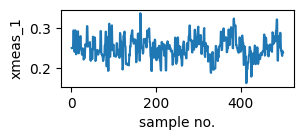

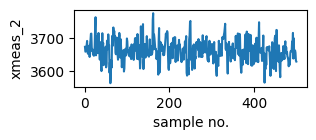

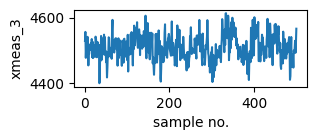

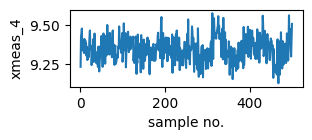

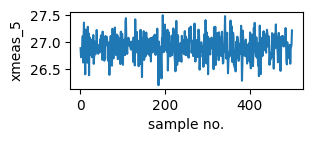

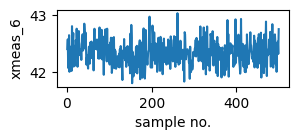

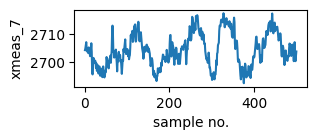

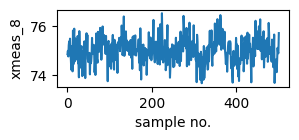

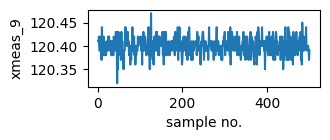

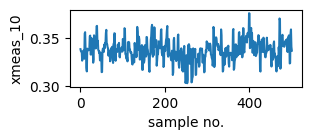

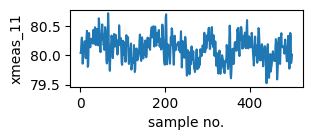

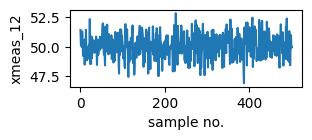

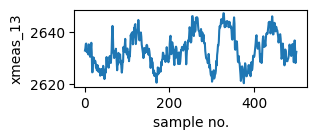

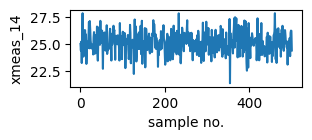

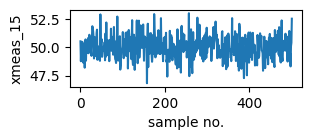

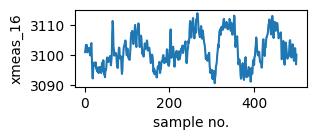

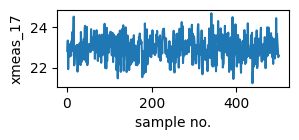

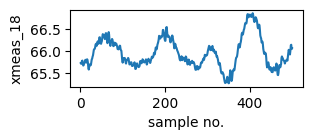

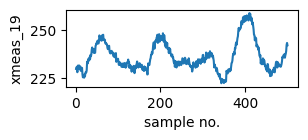

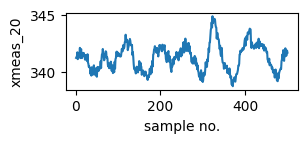

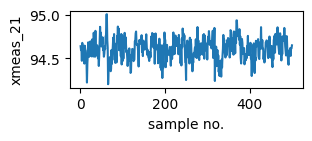

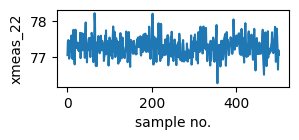

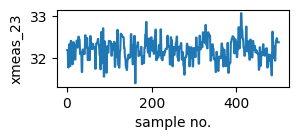

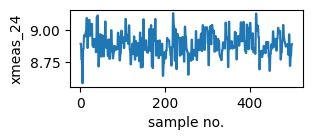

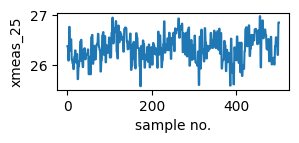

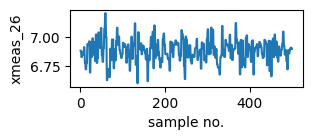

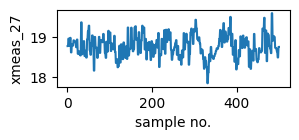

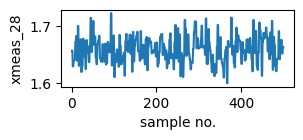

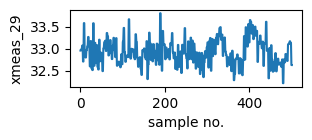

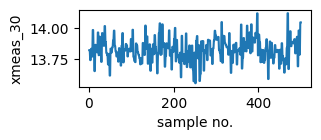

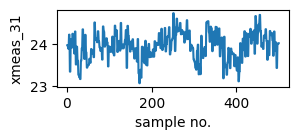

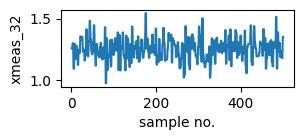

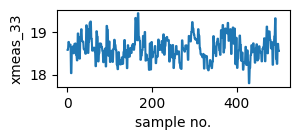

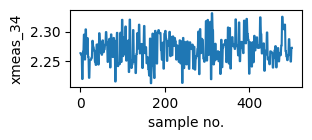

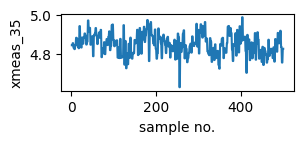

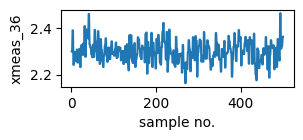

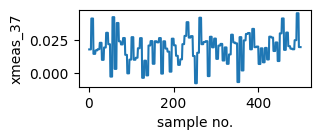

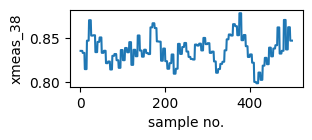

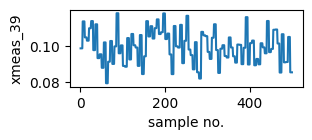

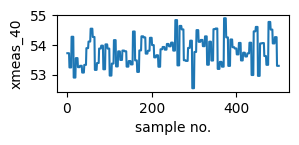

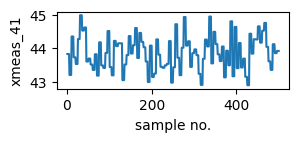

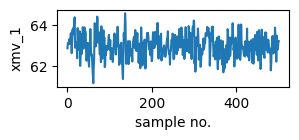

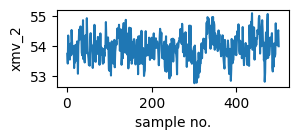

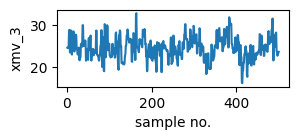

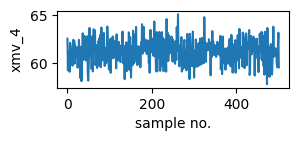

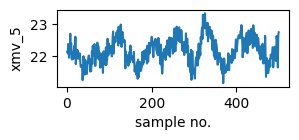

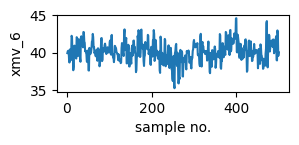

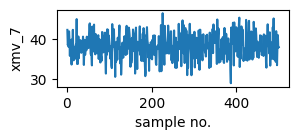

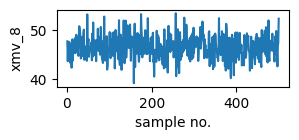

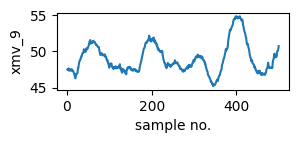

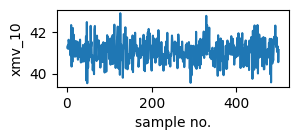

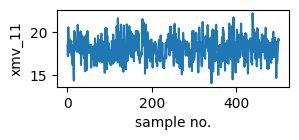

In [9]:
pp=DF[(DF['faultNumber']==0)&(DF['simulationRun']==1)]
for col in DF.columns[3:]:
    plt.rcParams['figure.figsize']=[3,1]
    plt.plot(pp['sample'],pp[col])
    plt.xlabel('sample no.')
    plt.ylabel(col)
    plt.show()